In [4]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.metrics import mean_squared_error
from train import run_optimized_pipeline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
test_df, wf_predictions, best_params = run_optimized_pipeline(
    file_path="SPY_VIX_daily_clean.parquet",
    n_trials=10,
    n_splits=4
)

1. Prepping Tensor Data for Optuna...
2. The Thunderdome (Running 10 Trials to find Architecture)...
--> Architecture Locked: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.1541168988591605, 'lr': 0.00778936896513396}
3. Executing Rolling Window Walk-Forward Validation (4 Eras)...
   -> Inducing Amnesia and Training Era 1/4...
   -> Inducing Amnesia and Training Era 2/4...
   -> Inducing Amnesia and Training Era 3/4...
   -> Inducing Amnesia and Training Era 4/4...


In [6]:
actual_vol = test_df['realized_vol'].values
dates = test_df.index
p10 = wf_predictions[:, 0]
p50 = wf_predictions[:, 1]
p90 = wf_predictions[:, 2]

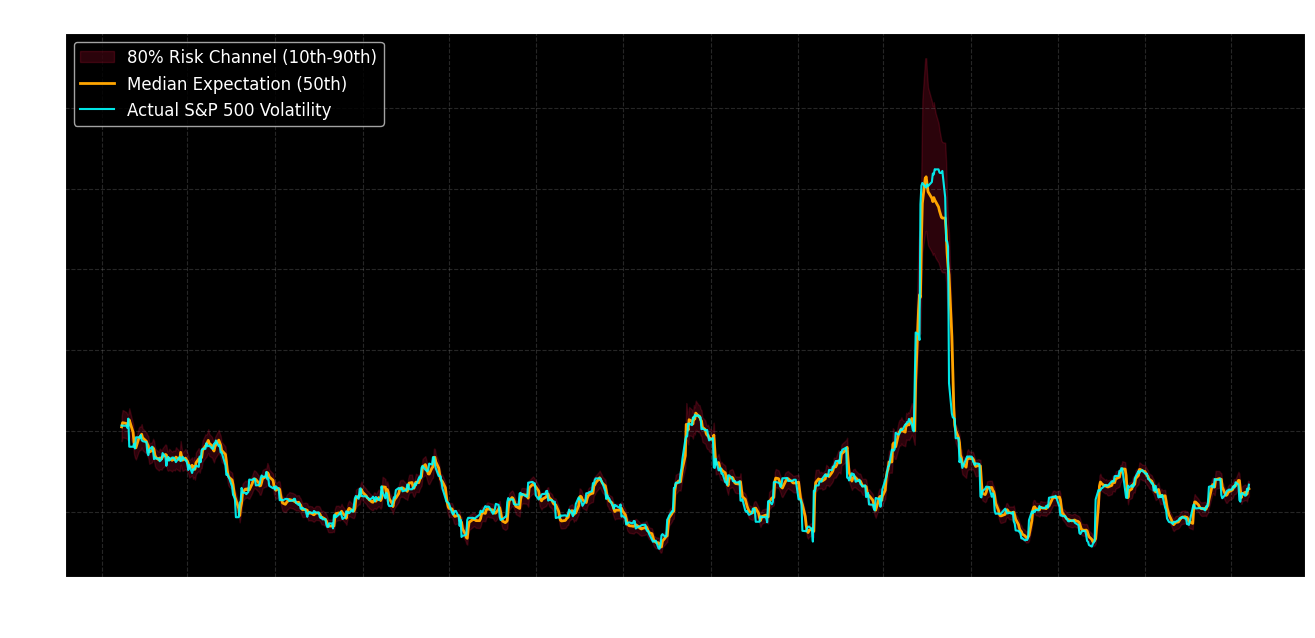

In [7]:
# Paint the canvas
plt.figure(figsize=(16, 8))
plt.style.use('dark_background') # Because light mode is for retail traders

# The Chaos Zone (80% Confidence Interval)
plt.fill_between(dates, p10, p90, color='crimson', alpha=0.2, label='80% Risk Channel (10th-90th)')

# The Median and The Truth
plt.plot(dates, p50, color='orange', linewidth=2, label='Median Expectation (50th)')
plt.plot(dates, actual_vol, color='cyan', linewidth=1.5, alpha=0.9, label='Actual S&P 500 Volatility')

# Formatting
plt.title('Institutional Alpha: Quantile Regression LSTM', fontsize=16, fontweight='bold')
plt.ylabel('Realized Volatility', fontsize=12)
plt.grid(color='gray', linestyle='--', alpha=0.3)
plt.legend(loc='upper left', fontsize=12)

# Make the dates readable
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gcf().autofmt_xdate()

plt.show()